In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector

from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
conn = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user = os.getenv('DB_USER'),
    password = os.getenv('DB_PASSWORD')
)


In [3]:
df = pd.read_sql("SELECT * FROM KohanNegar.order_detail2", conn)
print(df.head())
print('-'*50)
print(df.head(10))
print('-'*50)
print(df.tail()) 


   order_id  detail_id  product_id  quantity     price
0         1          1         104         1  19370000
1         2          3         120         1  30670000
2         3          8         116         2  23690000
3         4         10         140         1  30000000
4         5         11           3         1  13010000
--------------------------------------------------
   order_id  detail_id  product_id  quantity     price
0         1          1         104         1  19370000
1         2          3         120         1  30670000
2         3          8         116         2  23690000
3         4         10         140         1  30000000
4         5         11           3         1  13010000
5         6         13         132         2  24050000
6         7         14           7         1   4610000
7         8         19           9         1  11130000
8         9         20           2         1  11100000
9        10         21          48         1   4640000
--------------

/var/folders/h1/gmdl87ks4xqg31g3hddyxr4r0000gn/T/ipykernel_64625/3326034561.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM KohanNegar.order_detail2", conn)


In [4]:
print(df.shape)
print(df.columns)

(56, 5)
Index(['order_id', 'detail_id', 'product_id', 'quantity', 'price'], dtype='str')


In [5]:
print(df.info)

<bound method DataFrame.info of     order_id  detail_id  product_id  quantity      price
0          1          1         104         1   19370000
1          2          3         120         1   30670000
2          3          8         116         2   23690000
3          4         10         140         1   30000000
4          5         11           3         1   13010000
5          6         13         132         2   24050000
6          7         14           7         1    4610000
7          8         19           9         1   11130000
8          9         20           2         1   11100000
9         10         21          48         1    4640000
10        11         23         128         1   37190000
11        12         24         149         2  148370000
12        13         25          53         1   27340000
13        14         26         111         2   13840000
14        15         29          50         4    6220000
15        16         33          48         1    4640000

In [6]:
print(df.describe)

<bound method NDFrame.describe of     order_id  detail_id  product_id  quantity      price
0          1          1         104         1   19370000
1          2          3         120         1   30670000
2          3          8         116         2   23690000
3          4         10         140         1   30000000
4          5         11           3         1   13010000
5          6         13         132         2   24050000
6          7         14           7         1    4610000
7          8         19           9         1   11130000
8          9         20           2         1   11100000
9         10         21          48         1    4640000
10        11         23         128         1   37190000
11        12         24         149         2  148370000
12        13         25          53         1   27340000
13        14         26         111         2   13840000
14        15         29          50         4    6220000
15        16         33          48         1    46400

In [7]:
print(df['quantity'].describe())

count    56.000000
mean      1.178571
std       0.508371
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       4.000000
Name: quantity, dtype: float64


In [8]:
print(df.isnull().sum())

order_id      0
detail_id     0
product_id    0
quantity      0
price         0
dtype: int64


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = pd.read_sql("SELECT * FROM KohanNegar.orders", conn) 
print(df['order_date'].dtype)

datetime64[us]


/var/folders/h1/gmdl87ks4xqg31g3hddyxr4r0000gn/T/ipykernel_64625/812198704.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM KohanNegar.orders", conn)


In [11]:
print(df['order_date'].dt.year)

0       2026
1       2025
2       2026
3       2026
4       2026
        ... 
5671    2024
5672    2025
5673    2023
5674    2024
5675    2022
Name: order_date, Length: 5676, dtype: int32


In [12]:
print(df['order_date'].dt.month)

0        4
1        9
2        6
3        5
4        8
        ..
5671     3
5672     5
5673     3
5674     1
5675    12
Name: order_date, Length: 5676, dtype: int32


In [13]:
df = pd.read_sql("SELECT * FROM KohanNegar.order_detail2", conn)
df['sales'] = df['quantity'] * df['price']
print(df)

    order_id  detail_id  product_id  quantity      price      sales
0          1          1         104         1   19370000   19370000
1          2          3         120         1   30670000   30670000
2          3          8         116         2   23690000   47380000
3          4         10         140         1   30000000   30000000
4          5         11           3         1   13010000   13010000
5          6         13         132         2   24050000   48100000
6          7         14           7         1    4610000    4610000
7          8         19           9         1   11130000   11130000
8          9         20           2         1   11100000   11100000
9         10         21          48         1    4640000    4640000
10        11         23         128         1   37190000   37190000
11        12         24         149         2  148370000  296740000
12        13         25          53         1   27340000   27340000
13        14         26         111         2   

/var/folders/h1/gmdl87ks4xqg31g3hddyxr4r0000gn/T/ipykernel_64625/2667861078.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM KohanNegar.order_detail2", conn)


In [14]:
average_sales = np.mean(df['sales'])
print(average_sales)
print('-'*100)
max_sales = np.max(df['sales'])
print(max_sales)
print('-'*100)
min_sales = np.min(df['sales'])
print(min_sales)


35898928.571428575
----------------------------------------------------------------------------------------------------
296740000
----------------------------------------------------------------------------------------------------
2020000


In [15]:
total_sales = df['sales'].sum()
print(f' جمع فروش : {total_sales}')

 جمع فروش : 2010340000


In [16]:
mean_sales = df['sales'].mean()
print(f' میانگین فروش : {mean_sales}')

 میانگین فروش : 35898928.571428575


In [17]:
maximum_sales = df['sales'].max()
print(f'ببیشترین مقدار فروش: {maximum_sales}')

ببیشترین مقدار فروش: 296740000


In [18]:
product_sales = df.groupby('product_id')['sales'].sum()
product_sales = product_sales.sort_values(ascending=False)
print('product sales:', product_sales)

product sales: product_id
149    445110000
153    348180000
182    163380000
160    134730000
128     74380000
181     64300000
109     61850000
111     55360000
132     48100000
116     47380000
125     46960000
105     41550000
2       33300000
120     30670000
140     30000000
53      27340000
50      24880000
52      22350000
9       22260000
8       22110000
104     19370000
5       17010000
152     16560000
136     16220000
76      15640000
44      14550000
38      13600000
119     13370000
3       13010000
115     12940000
16      11670000
138     11360000
41      10840000
133     10760000
131     10270000
123     10250000
82       9300000
48       9280000
7        9220000
6        8090000
28       5440000
15       5380000
45       2020000
Name: sales, dtype: int64


In [19]:
users = pd.read_sql("SELECT users.id as 'user_id', users.user_name,users.city FROM KohanNegar.users", conn)
orders = pd.read_sql("SELECT orders.id as 'order_id', orders.user_id FROM KohanNegar.orders", conn)

/var/folders/h1/gmdl87ks4xqg31g3hddyxr4r0000gn/T/ipykernel_64625/3572892387.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  users = pd.read_sql("SELECT users.id as 'user_id', users.user_name,users.city FROM KohanNegar.users", conn)
/var/folders/h1/gmdl87ks4xqg31g3hddyxr4r0000gn/T/ipykernel_64625/3572892387.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql("SELECT orders.id as 'order_id', orders.user_id FROM KohanNegar.orders", conn)


In [20]:
result_1 = pd.merge(orders, users, left_on = 'user_id', right_on='user_id', how='inner')
result_1

,order_id,user_id,user_name,city
0,36,10,hamidreza.afshar,Rasht
1,37,10,hamidreza.afshar,Rasht
2,38,10,hamidreza.afshar,Rasht
3,39,10,hamidreza.afshar,Rasht
4,40,10,hamidreza.afshar,Rasht
...,...,...,...,...
5671,3944,997,navid.eshghi,Bandar Anzali
5672,3945,997,navid.eshghi,Bandar Anzali
5673,3946,997,navid.eshghi,Bandar Anzali
5674,3947,997,navid.eshghi,Bandar Anzali


In [21]:
result_2 = pd.read_sql("SELECT order_id, total_amount FROM KohanNegar.payments", conn)
result_2

/var/folders/h1/gmdl87ks4xqg31g3hddyxr4r0000gn/T/ipykernel_64625/1507164265.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_2 = pd.read_sql("SELECT order_id, total_amount FROM KohanNegar.payments", conn)


,order_id,total_amount
0,1,49370000
1,2,90930000
2,4,27000000
3,5,18680000
4,6,40885000
...,...,...
3696,5671,216810000
3697,5673,7785000
3698,5674,7370000
3699,5675,25290000


In [22]:
result_3 = pd.merge(result_1, result_2, on='order_id', how='inner')
result_3

,order_id,user_id,user_name,city,total_amount
0,36,10,hamidreza.afshar,Rasht,19958000
1,37,10,hamidreza.afshar,Rasht,39980000
2,39,10,hamidreza.afshar,Rasht,5670000
3,40,10,hamidreza.afshar,Rasht,69090000
4,41,10,hamidreza.afshar,Rasht,20077000
...,...,...,...,...,...
3696,3944,997,navid.eshghi,Bandar Anzali,197980000
3697,3945,997,navid.eshghi,Bandar Anzali,51880000
3698,3946,997,navid.eshghi,Bandar Anzali,78552000
3699,3947,997,navid.eshghi,Bandar Anzali,516170000


In [23]:
city_sales = result_3.groupby('city')['total_amount'].sum()
city_sales = city_sales.sort_values(ascending=False)
city_sales

city
Rasht            210785364000
Nowshahr          95509980000
Bandar Anzali     72328970000
Name: total_amount, dtype: int64

## 13. 

pd.read_sql()

In [24]:
pd.read_sql('SELECT od2.order_id,od2.product_id, od2.quantity,p.title FROM order_detail2 AS od2 JOIN products AS pON p.id = od2.product_id;',conn)

/var/folders/h1/gmdl87ks4xqg31g3hddyxr4r0000gn/T/ipykernel_64625/3447603025.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql('SELECT od2.order_id,od2.product_id, od2.quantity,p.title FROM order_detail2 AS od2 JOIN products AS pON p.id = od2.product_id;',conn)


ProgrammingError: 1064 (42000): You have an error in your SQL syntax; check the manual that corresponds to your MySQL server version for the right syntax to use near 'p.id = od2.product_id' at line 1

## 14.

In [26]:
df = pd.read_sql("SELECT * FROM KohanNegar.payments", conn)
df['month'] = df['payment_date'].dt.month
monthly_sales = df.groupby("month")['total_amount'].sum()
monthly_sales = monthly_sales.sort_values(ascending=False)
print('monthly sales', monthly_sales)

monthly sales month
7     47285032000
6     37119915000
1     35812106000
2     33822696000
3     33558235000
12    32463167000
5     31493795000
11    31066000000
8     29544171000
9     28681395000
4     22538048000
10    15239754000
Name: total_amount, dtype: int64


/var/folders/h1/gmdl87ks4xqg31g3hddyxr4r0000gn/T/ipykernel_64625/4014613936.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM KohanNegar.payments", conn)


## 15.

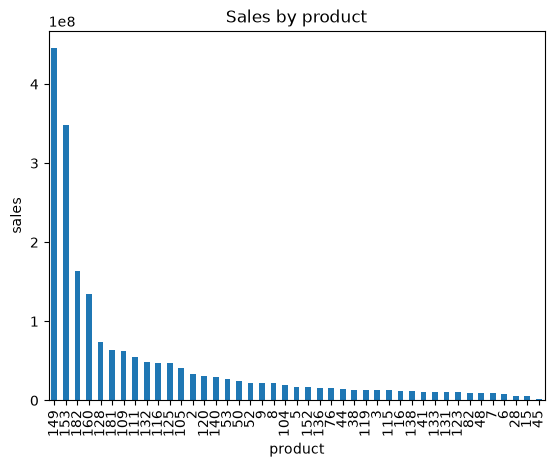

In [29]:
product_sales.plot(kind='bar')
plt.title('Sales by product')
plt.xlabel('product')
plt.ylabel('sales')
plt.show()

## 16.

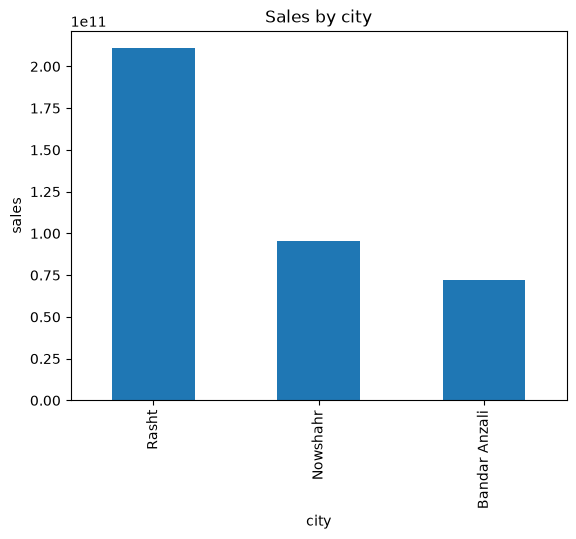

In [32]:
city_sales.plot(kind = 'bar')
plt.title('Sales by city')
plt.xlabel('city')
plt.ylabel('sales')
plt.show()

## 17.

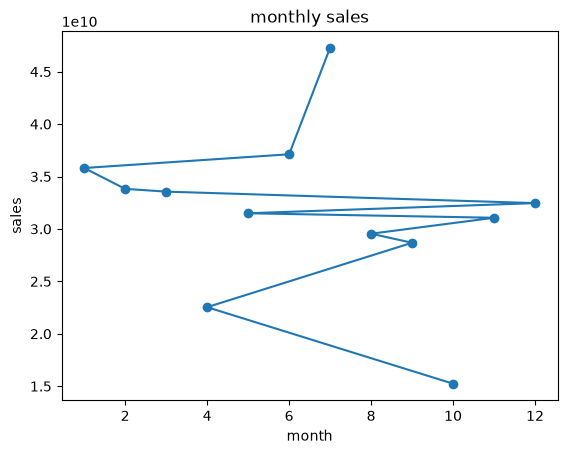

In [34]:
monthly_sales.plot(kind='line', marker= 'o')
plt.title('monthly sales')
plt.xlabel('month')
plt.ylabel('sales')
plt.show()

## 18.

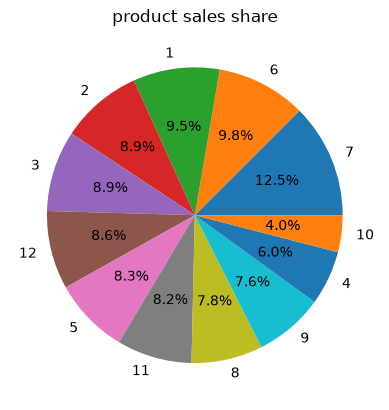

In [37]:
monthly_sales.plot(kind='pie',autopct = '%1.1f%%')
plt.title('product sales share')
plt.show()